In [41]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def fit_threshold_curve(folder,
                        time=None,
                        method="HSV",
                        lower_hsv=[0, 75, 95],
                        upper_hsv=[360, 80, 100],
                        fit_type="auto"):
    """
    对单个文件夹执行阈值拟合，可选分数幂(0-1)、对数、线性拟合。
    返回拟合的曲线并可视化，图例上显示拟合方程式、R²、RMSE。
    若给定 time，则返回该时间在拟合曲线上的预测结果，并用红点标出。

    Parameters:
        folder (str): 文件夹路径
        time (float): 预测时间点（秒），可选
        method (str): 目前仅支持 "HSV"
        lower_hsv, upper_hsv (list): HSV阈值区间
        fit_type (str): "auto" | "log" | "linear" | "power"
                        auto 时自动在三种模型中选择 R² 最优且满足约束的模型

    Returns:
        float or None: 给定 time 时的预测 volume，若 time 为 None 则返回 None
    """
    fit_type = fit_type.lower()
    if fit_type not in ("auto", "log", "linear", "power"):
        raise ValueError("fit_type 必须是 'auto'、'log'、'linear' 或 'power' 之一")

    # 读取数据
    all_curves = batch_fit_color_curves(folder)

    # 提取满足阈值条件的 (time, volume) 点
    vol_time_dict = {}
    for vol_name, curves in all_curves.items():
        vol = float(vol_name)
        t = curves['time']
        matched = np.ones_like(t, dtype=bool)
        for p, lc, uc in zip(['H', 'S', 'V'], lower_hsv, upper_hsv):
            matched = matched & (curves[p] >= lc) & (curves[p] <= uc)
        idx = np.where(matched)[0]
        if len(idx) > 0:
            vol_time_dict[vol] = t[idx[0]]

    if len(vol_time_dict) < 2:
        raise ValueError(f"满足阈值条件的用量不足（仅 {len(vol_time_dict)} 个），无法拟合")

    volumes = np.array(list(vol_time_dict.keys()))
    times = np.array(list(vol_time_dict.values()))
    sort_idx = np.argsort(times)
    times = times[sort_idx]
    volumes = volumes[sort_idx]

    # 模型定义
    def log_model(t, a, b, c):
        return a * np.log(b * t + c)
    def linear_model(t, a, b):
        return a * t + b
    def power_model(t, a, b, c):
        return a * np.power(t, b) + c

    # 通用拟合尝试函数
    def _try_fit(model_func, p0, bounds, valid, name, formula_fmt):
        try:
            popt, _ = curve_fit(model_func, times, volumes, p0=p0, bounds=bounds, maxfev=20000)
            if valid is not None and not valid(popt):
                return None
            fitted = lambda t, p=popt: model_func(t, *p)
            v_pred = fitted(times)
            ss_res = ((volumes - v_pred) ** 2).sum()
            v_mean = volumes.mean()
            ss_tot = ((volumes - v_mean) ** 2).sum()
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
            rmse = np.sqrt(ss_res / len(times))
            formula = formula_fmt(*popt)
            return {
                'func': fitted, 'name': name, 'formula': formula,
                'r2': r2, 'rmse': rmse, 'popt': popt
            }
        except Exception:
            return None

    candidates = []

    # 对数拟合
    if fit_type in ("auto", "log"):
        res = _try_fit(
            log_model, p0=[1.0, 1.0, 1.0],
            bounds=([-np.inf, 1e-8, 1e-8], [np.inf, np.inf, np.inf]),
            valid=lambda p: p[0] > 0 and np.all(p[1] * times + p[2] > 0),
            name="log",
            formula_fmt=lambda a, b, c: f"V(t) = {a:.4f}·ln({b:.4f}·t + {c:.4f})"
        )
        if res:
            candidates.append(res)
        elif fit_type == "log":
            raise RuntimeError("对数模型拟合失败或参数不满足约束")

    # 线性拟合
    if fit_type in ("auto", "linear"):
        res = _try_fit(
            linear_model, p0=[1.0, 0.0],
            bounds=([-np.inf, -np.inf], [np.inf, np.inf]),
            valid=lambda p: p[0] > 0,
            name="linear",
            formula_fmt=lambda a, b: f"V(t) = {a:.4f}·t + {b:.4f}"
        )
        if res:
            candidates.append(res)
        elif fit_type == "linear":
            raise RuntimeError("线性模型拟合失败或斜率不满足单调递增约束")

    # 分数幂拟合 (0 < b ≤ 1)
    if fit_type in ("auto", "power"):
        res = _try_fit(
            power_model, p0=[1.0, 0.5, 0.0],
            bounds=([0, 1e-6, -np.inf], [np.inf, 1.0, np.inf]),
            valid=lambda p: p[0] > 0,
            name="power",
            formula_fmt=lambda a, b, c: f"V(t) = {a:.4f}·t^{b:.4f} + {c:.4f}"
        )
        if res:
            candidates.append(res)
        elif fit_type == "power":
            raise RuntimeError("分数幂模型拟合失败或参数不满足约束")

    if not candidates:
        raise RuntimeError("所有候选模型均拟合失败")

    # auto 模式下选择 R² 最高的模型
    best = max(candidates, key=lambda x: x['r2'])
    fitted_curve = best['func']
    fit_method = best['name']
    formula_text = best['formula']
    r2 = best['r2']
    rmse = best['rmse']

    # 预测
    predicted_volume = None
    if time is not None:
        predicted_volume = float(fitted_curve(time))

    # 可视化
    t_dense = np.linspace(times.min(), times.max(), 500)
    v_dense = fitted_curve(t_dense)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(times, volumes, color='black', zorder=5, label='Data points')
    line_label = f"{formula_text}\nR² = {r2:.4f}, RMSE = {rmse:.4f}"
    ax.plot(t_dense, v_dense, color='blue', linewidth=2, label=line_label)

    if predicted_volume is not None:
        ax.scatter([time], [predicted_volume], color='red', s=100, zorder=6,
                   label=f'Prediction ({time:.2f}s, {predicted_volume:.2f})')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Volume')
    ax.set_title(f'Threshold Fit ({fit_method})\n(HSV lower={lower_hsv}, upper={upper_hsv})')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return predicted_volume


文件格式格式及颜色表示格式解释：
文件名为加入量，列名分别代表："Time(s)" 时间； H(0-360) 即Hue（色相）颜色的基本种类，对应色轮上的角度；S (0-100) 即Saturation（饱和度）颜色的纯度或鲜艳程度； V (0-100) 即Value（明度/亮度）颜色的明暗程度

R、G、B分别代表红（Red）、绿（Green）、蓝（Blue）三个颜色通道的光强度，每个数值表示该颜色光的亮度等级（常见范围0-255或0-100%）

环境光变化：
对RGB而言，三个通道数值同时同向增减（整体变亮或变暗），但比例基本保持
对HSV而言，V成比例变化，而 H保持不变，S在过暗或过曝时下降。


In [42]:
import pandas as pd

filepath = r"C:\Users\abc\Desktop\excel\excel\200.xlsx"
df = pd.read_excel(filepath)
print(df)

      Time (s)  H (0-360)  S (0-100)  V (0-100)
0     0.086752   172.9868  12.828588  68.196235
1     0.176990   173.0348  12.823176  68.280196
2     0.253718   170.8884  12.630667  68.352431
3     0.329119   172.4578  12.472627  68.434431
4     0.408708   170.8020  12.601137  68.437451
..         ...        ...        ...        ...
334  18.568064    47.8174  89.793098  54.711333
335  18.619906    47.5950  90.454000  54.547294
336  18.673647    47.2426  90.915451  54.518980
337  18.727587    45.9984  92.548941  54.277804
338  18.779932    45.7236  92.808471  54.171647

[339 rows x 4 columns]


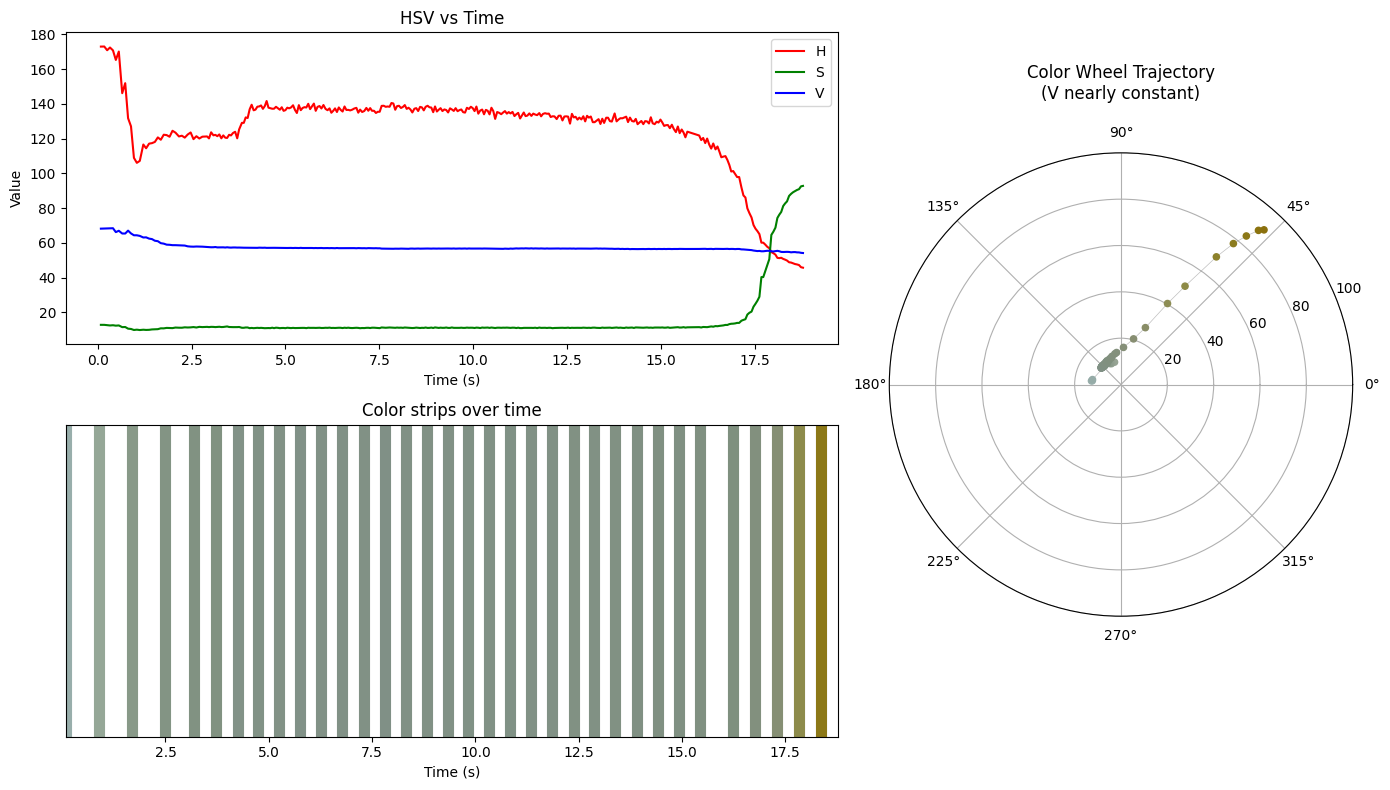

In [43]:
import matplotlib.pyplot as plt
import colorsys
import numpy as np

df['R'], df['G'], df['B'] = zip(*df.apply(
    lambda row: colorsys.hsv_to_rgb(row['H (0-360)']/360, row['S (0-100)']/100, row['V (0-100)']/100), axis=1))

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1.2])

# HSV vs Time
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(df['Time (s)'], df['H (0-360)'], label='H', color='red')
ax0.plot(df['Time (s)'], df['S (0-100)'], label='S', color='green')
ax0.plot(df['Time (s)'], df['V (0-100)'], label='V', color='blue')
ax0.set_xlabel('Time (s)')
ax0.set_ylabel('Value')
ax0.legend()
ax0.set_title('HSV vs Time')

# Color strips
ax1 = fig.add_subplot(gs[1, 0])
for i in range(0, len(df), 10):
    ax1.axvline(df['Time (s)'].iloc[i], color=(df['R'].iloc[i], df['G'].iloc[i], df['B'].iloc[i]), linewidth=8)
ax1.set_xlabel('Time (s)')
ax1.set_title('Color strips over time')
ax1.set_xlim(df['Time (s)'].min(), df['Time (s)'].max())
ax1.set_yticks([])

# Color wheel (polar plot) — V is nearly constant, so H-S plane shows the color change
ax2 = fig.add_subplot(gs[:, 1], projection='polar')
sample_idx = range(0, len(df), 3)
theta = df['H (0-360)'].iloc[sample_idx].values * np.pi / 180
r = df['S (0-100)'].iloc[sample_idx].values
colors_rgb = [(df['R'].iloc[i], df['G'].iloc[i], df['B'].iloc[i]) for i in sample_idx]

ax2.plot(theta, r, color='gray', linewidth=0.5, alpha=0.5)
ax2.scatter(theta, r, c=colors_rgb, s=20, zorder=5)
ax2.set_theta_zero_location('E')
ax2.set_theta_direction(1)
ax2.set_ylim(0, 100)
ax2.set_title('Color Wheel Trajectory\n(V nearly constant)', pad=20)

plt.tight_layout()
plt.show()

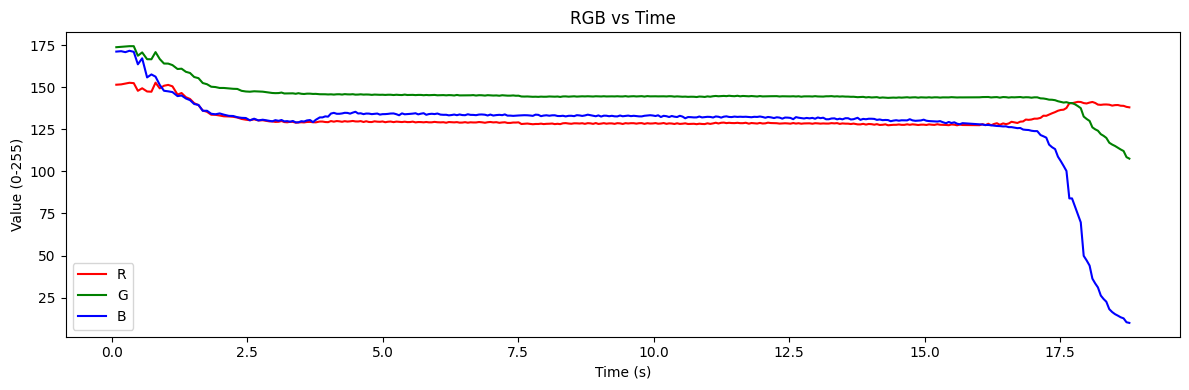

In [44]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['Time (s)'], df['R']*255, label='R', color='red')
ax.plot(df['Time (s)'], df['G']*255, label='G', color='green')
ax.plot(df['Time (s)'], df['B']*255, label='B', color='blue')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Value (0-255)')
ax.legend()
ax.set_title('RGB vs Time')
plt.tight_layout()
plt.show()

可以注意到由于采样时的波动，曲线呈锯齿状，这是由于传感器得到的数据含有噪声；同时注意到肉眼及计算机趋势均可以看出颜色并未突变而是存在一个渐进的过程，故选择在拟合前对数据进行预处理，对传感器得到的数据进行样条拟合。

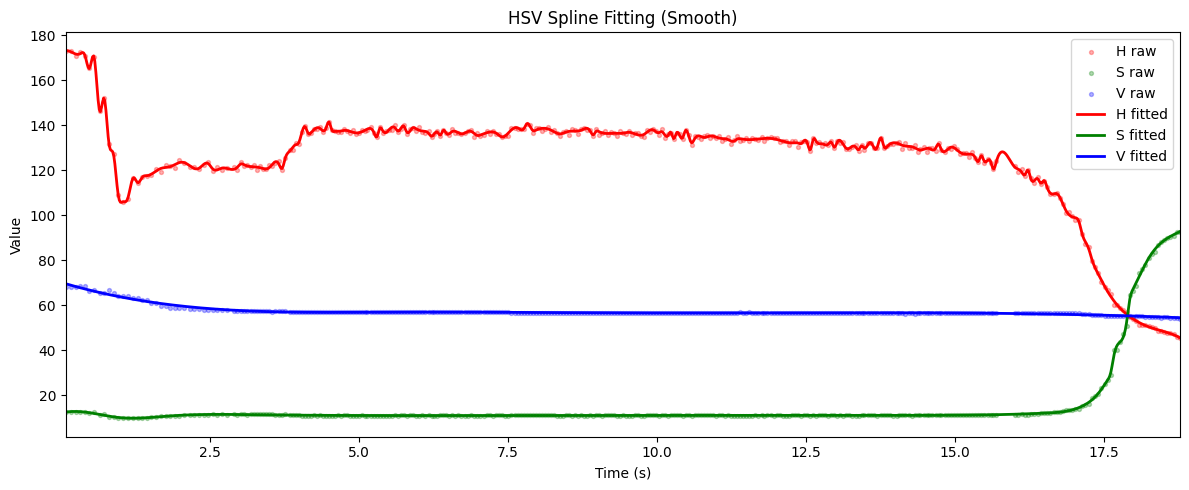

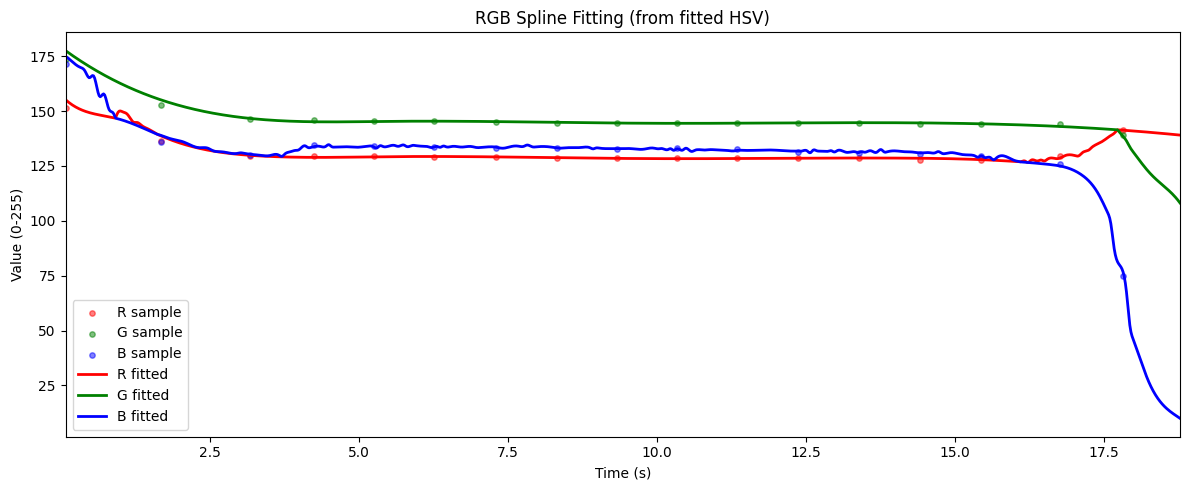

In [45]:
from scipy.interpolate import UnivariateSpline
import numpy as np
import matplotlib.pyplot as plt
import colorsys

# 使用全部采样点
x = df['Time (s)'].values
h = df['H (0-360)'].values
s = df['S (0-100)'].values
v = df['V (0-100)'].values

# 平滑样条拟合（s 控制平滑程度，越大越平滑）
# 经验法则：s ≈ 数据点数 × 噪声方差，这里取一个适中的值
t_dense = np.linspace(x.min(), x.max(), 1000)
spl_h = UnivariateSpline(x, h, s=len(x) * 0.5)
spl_s = UnivariateSpline(x, s, s=len(x) * 0.1)
spl_v = UnivariateSpline(x, v, s=len(x) * 0.1)

h_fit = spl_h(t_dense)
s_fit = spl_s(t_dense)
v_fit = spl_v(t_dense)

# 限制取值范围
h_fit = np.clip(h_fit, 0, 360)
s_fit = np.clip(s_fit, 0, 100)
v_fit = np.clip(v_fit, 0, 100)

# 将拟合后的HSV转为RGB
r_fit, g_fit, b_fit = zip(*[
    colorsys.hsv_to_rgb(h/360, s/100, v/100) for h, s, v in zip(h_fit, s_fit, v_fit)
])
r_fit = np.array(r_fit) * 255
g_fit = np.array(g_fit) * 255
b_fit = np.array(b_fit) * 255

# 原始RGB（用于绘制原始采样点）—— 每隔 20 个点画一个点，避免图上太密
r_sample = df['R'].iloc[::20].values * 255
g_sample = df['G'].iloc[::20].values * 255
b_sample = df['B'].iloc[::20].values * 255
t_sample = df['Time (s)'].iloc[::20].values

# 图1：HSV拟合结果
fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.scatter(x, h, color='red', s=8, alpha=0.3, label='H raw')
ax1.scatter(x, s, color='green', s=8, alpha=0.3, label='S raw')
ax1.scatter(x, v, color='blue', s=8, alpha=0.3, label='V raw')
ax1.plot(t_dense, h_fit, color='red', linewidth=2, label='H fitted')
ax1.plot(t_dense, s_fit, color='green', linewidth=2, label='S fitted')
ax1.plot(t_dense, v_fit, color='blue', linewidth=2, label='V fitted')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Value')
ax1.set_title('HSV Spline Fitting (Smooth)')
ax1.legend()
ax1.set_xlim(x.min(), x.max())
plt.tight_layout()
plt.show()

# 图2：RGB拟合结果
fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.scatter(t_sample, r_sample, color='red', s=15, alpha=0.5, label='R sample')
ax2.scatter(t_sample, g_sample, color='green', s=15, alpha=0.5, label='G sample')
ax2.scatter(t_sample, b_sample, color='blue', s=15, alpha=0.5, label='B sample')
ax2.plot(t_dense, r_fit, color='red', linewidth=2, label='R fitted')
ax2.plot(t_dense, g_fit, color='green', linewidth=2, label='G fitted')
ax2.plot(t_dense, b_fit, color='blue', linewidth=2, label='B fitted')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Value (0-255)')
ax2.set_title('RGB Spline Fitting (from fitted HSV)')
ax2.legend()
ax2.set_xlim(x.min(), x.max())
plt.tight_layout()
plt.show()

In [46]:
import os
import pandas as pd
from scipy.interpolate import UnivariateSpline

def fit_color_curves(filepath):
    """
    读取颜色数据Excel文件，对HSV进行平滑样条拟合，并生成对应的RGB曲线。
    
    Parameters:
        filepath (str): Excel文件路径
        
    Returns:
        volume (str): 用量
        curves (dict): 包含拟合后6条曲线的字典
                       {'H', 'S', 'V', 'R', 'G', 'B'}
    """
    df = pd.read_excel(filepath)
    
    x = df['Time (s)'].values
    h = df['H (0-360)'].values
    s = df['S (0-100)'].values
    v = df['V (0-100)'].values
    
    # 平滑样条拟合
    t_dense = np.linspace(x.min(), x.max(), 1000)
    spl_h = UnivariateSpline(x, h, s=len(x) * 0.5)
    spl_s = UnivariateSpline(x, s, s=len(x) * 0.1)
    spl_v = UnivariateSpline(x, v, s=len(x) * 0.1)
    
    h_fit = np.clip(spl_h(t_dense), 0, 360)
    s_fit = np.clip(spl_s(t_dense), 0, 100)
    v_fit = np.clip(spl_v(t_dense), 0, 100)
    
    # HSV -> RGB
    r_fit, g_fit, b_fit = zip(*[
        colorsys.hsv_to_rgb(h/360, s/100, v/100) for h, s, v in zip(h_fit, s_fit, v_fit)
    ])
    
    volume = os.path.splitext(os.path.basename(filepath))[0]
    curves = {
        'time': t_dense,
        'H': h_fit,
        'S': s_fit,
        'V': v_fit,
        'R': np.array(r_fit) * 255,
        'G': np.array(g_fit) * 255,
        'B': np.array(b_fit) * 255,
    }
    return volume, curves

现在，对文件夹中的所有记录文件执行拟合操作

In [47]:
import glob
import os

def batch_fit_color_curves(folder_path):
    """
    对文件夹中所有Excel记录文件执行拟合操作。
    
    Parameters:
        folder_path (str): 文件夹路径
        
    Returns:
        all_curves (dict): 大字典，键为文件名（去后缀），值为 curves 字典
    """
    all_curves = {}
    files = []
    for p in [os.path.join(folder_path, '*.xlsx'), os.path.join(folder_path, '*.xls')]:
        files.extend(glob.glob(p))
    
    for filepath in files:
        # 跳过非文件项（如目录）
        if not os.path.isfile(filepath):
            continue
        # 跳过临时文件（~$ 开头）
        if os.path.basename(filepath).startswith('~$'):
            continue
        try:
            volume, curves = fit_color_curves(filepath)
            all_curves[volume] = curves
            print(f"已处理: {volume} ({filepath})")
        except Exception as e:
            print(f"跳过文件 {filepath}: {e}")
    
    return all_curves

# 示例调用
# folder = r"C:\Users\abc\Desktop\afternoon"
# result_dict = batch_fit_color_curves(folder)
# print(f"\n共处理 {len(result_dict)} 个文件")

In [48]:
folder = r"C:\Users\abc\Desktop\excel\afternoon"
result_dict = batch_fit_color_curves(folder)

已处理: 125 (C:\Users\abc\Desktop\excel\afternoon\125.xlsx)
已处理: 175 (C:\Users\abc\Desktop\excel\afternoon\175.xlsx)
已处理: 225 (C:\Users\abc\Desktop\excel\afternoon\225.xlsx)
已处理: 275 (C:\Users\abc\Desktop\excel\afternoon\275.xlsx)
已处理: 320 (C:\Users\abc\Desktop\excel\afternoon\320.xlsx)
已处理: 325 (C:\Users\abc\Desktop\excel\afternoon\325.xlsx)
已处理: 340 (C:\Users\abc\Desktop\excel\afternoon\340.xlsx)
已处理: 360 (C:\Users\abc\Desktop\excel\afternoon\360.xlsx)
已处理: 375 (C:\Users\abc\Desktop\excel\afternoon\375.xlsx)
已处理: 380 (C:\Users\abc\Desktop\excel\afternoon\380.xlsx)
已处理: 420 (C:\Users\abc\Desktop\excel\afternoon\420.xlsx)
已处理: 425 (C:\Users\abc\Desktop\excel\afternoon\425.xlsx)
已处理: 440 (C:\Users\abc\Desktop\excel\afternoon\440.xlsx)
已处理: 460 (C:\Users\abc\Desktop\excel\afternoon\460.xlsx)
已处理: 475 (C:\Users\abc\Desktop\excel\afternoon\475.xlsx)
已处理: 480 (C:\Users\abc\Desktop\excel\afternoon\480.xlsx)
已处理: 520 (C:\Users\abc\Desktop\excel\afternoon\520.xlsx)
已处理: 525 (C:\Users\abc\Desktop\

已处理: 125 (C:\Users\abc\Desktop\excel\afternoon\125.xlsx)
已处理: 175 (C:\Users\abc\Desktop\excel\afternoon\175.xlsx)
已处理: 225 (C:\Users\abc\Desktop\excel\afternoon\225.xlsx)
已处理: 275 (C:\Users\abc\Desktop\excel\afternoon\275.xlsx)
已处理: 320 (C:\Users\abc\Desktop\excel\afternoon\320.xlsx)
已处理: 325 (C:\Users\abc\Desktop\excel\afternoon\325.xlsx)
已处理: 340 (C:\Users\abc\Desktop\excel\afternoon\340.xlsx)
已处理: 360 (C:\Users\abc\Desktop\excel\afternoon\360.xlsx)
已处理: 375 (C:\Users\abc\Desktop\excel\afternoon\375.xlsx)
已处理: 380 (C:\Users\abc\Desktop\excel\afternoon\380.xlsx)
已处理: 420 (C:\Users\abc\Desktop\excel\afternoon\420.xlsx)
已处理: 425 (C:\Users\abc\Desktop\excel\afternoon\425.xlsx)
已处理: 440 (C:\Users\abc\Desktop\excel\afternoon\440.xlsx)
已处理: 460 (C:\Users\abc\Desktop\excel\afternoon\460.xlsx)
已处理: 475 (C:\Users\abc\Desktop\excel\afternoon\475.xlsx)
已处理: 480 (C:\Users\abc\Desktop\excel\afternoon\480.xlsx)
已处理: 520 (C:\Users\abc\Desktop\excel\afternoon\520.xlsx)
已处理: 525 (C:\Users\abc\Desktop\

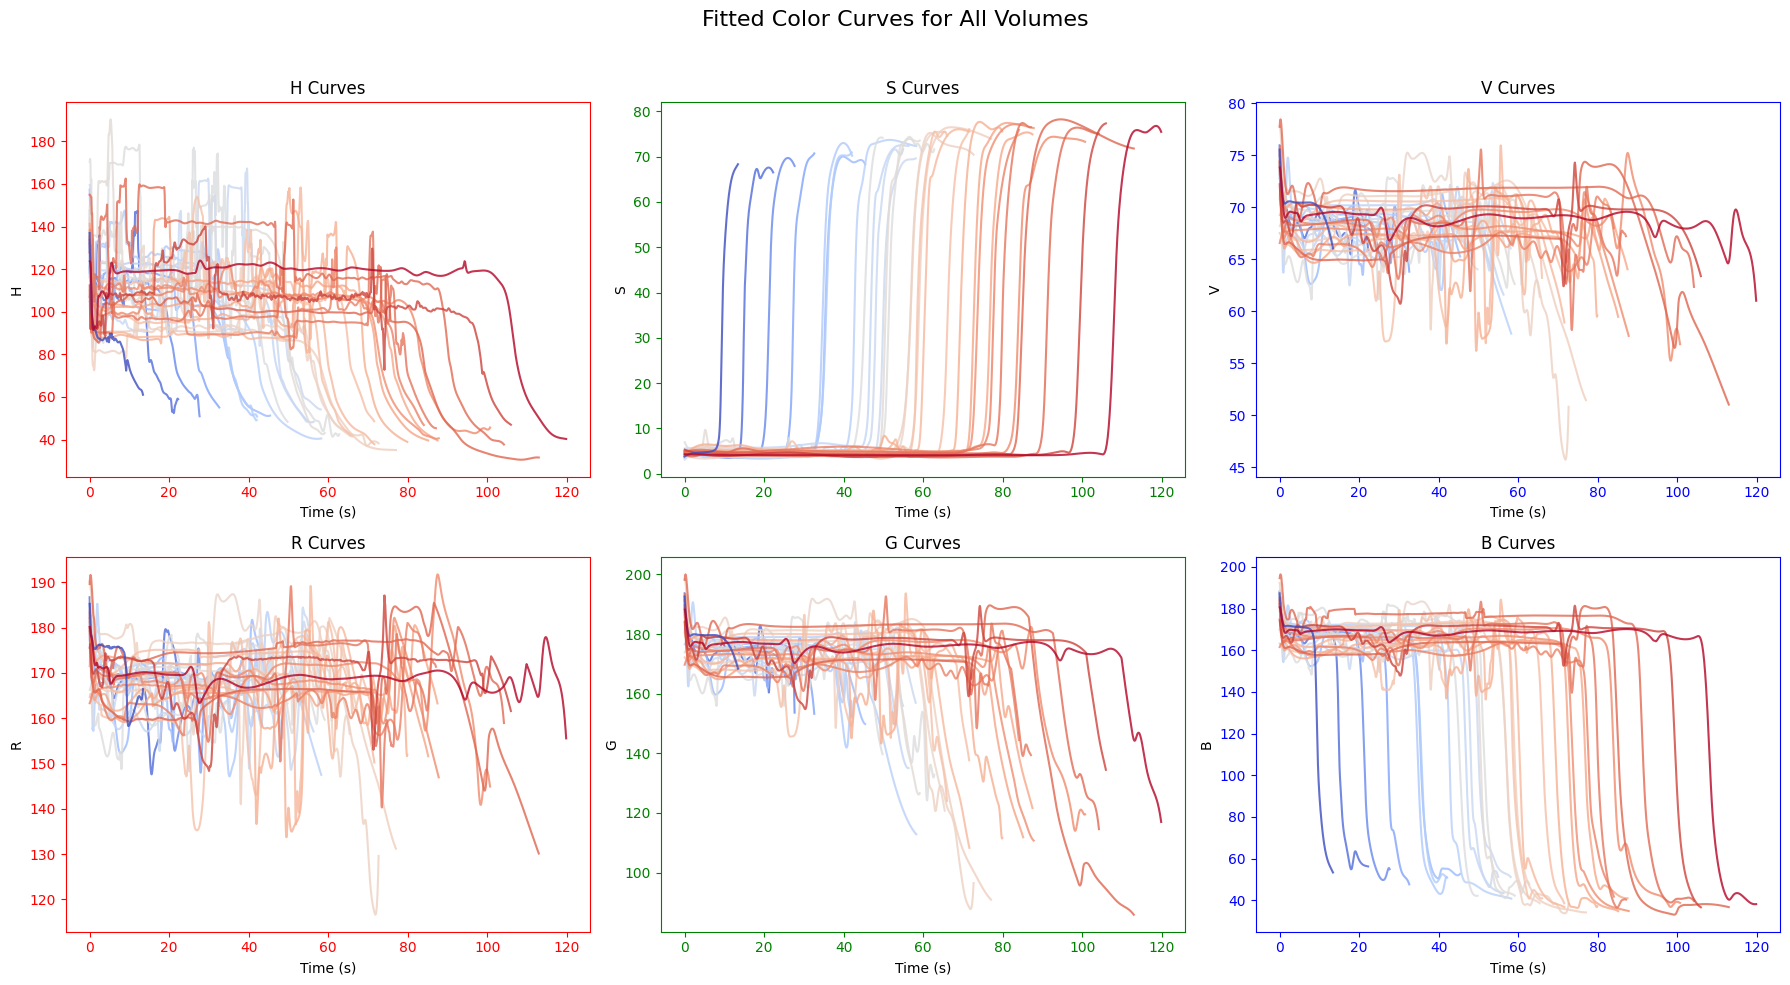

In [49]:
import matplotlib.pyplot as plt

def plot_all_volumes(all_curves):
    """
    将所有用量的 H、S、V、R、G、B 拟合曲线分别绘制在 6 张子图中。
    键名代表的数字越大，曲线颜色越红；越小越蓝。
    
    Parameters:
        all_curves (dict): batch_fit_color_curves 返回的大字典，
                           键为文件名（去后缀），值为 curves 字典
    """
    channels = ['H', 'S', 'V', 'R', 'G', 'B']
    colors = {'H': 'red', 'S': 'green', 'V': 'blue',
              'R': 'red', 'G': 'green', 'B': 'blue'}
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # 根据键名数字大小计算颜色深浅
    volumes_sorted = sorted(all_curves.keys(), key=lambda x: float(x))
    min_vol = float(volumes_sorted[0])
    max_vol = float(volumes_sorted[-1])
    vol_range = max_vol - min_vol if max_vol != min_vol else 1.0
    
    for idx, ch in enumerate(channels):
        ax = axes[idx]
        for volume, curves in all_curves.items():
            norm = (float(volume) - min_vol) / vol_range
            line_color = plt.cm.coolwarm(norm)
            ax.plot(curves['time'], curves[ch], color=line_color, alpha=0.8)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ch)
        ax.set_title(f'{ch} Curves')
        # 根据通道类型设置统一颜色提示（可选）
        for spine in ax.spines.values():
            spine.set_edgecolor(colors[ch])
        ax.tick_params(axis='both', colors=colors[ch])
    
    plt.suptitle('Fitted Color Curves for All Volumes', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# 示例调用
result_dict = batch_fit_color_curves(r"C:\Users\abc\Desktop\excel\afternoon")
plot_all_volumes(result_dict)

In [50]:
def plot_all_derivatives(all_curves):
    """
    将所有用量的 H、S、V、R、G、B 变化速度（一阶导数）分别绘制在 6 张子图中。
    键名代表的数字越大，曲线颜色越红；越小越蓝。
    
    Parameters:
        all_curves (dict): batch_fit_color_curves 返回的大字典，
                           键为文件名（去后缀），值为 curves 字典
    """
    channels = ['H', 'S', 'V', 'R', 'G', 'B']
    colors = {'H': 'red', 'S': 'green', 'V': 'blue',
              'R': 'red', 'G': 'green', 'B': 'blue'}
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # 根据键名数字大小计算颜色深浅
    volumes_sorted = sorted(all_curves.keys(), key=lambda x: float(x))
    min_vol = float(volumes_sorted[0])
    max_vol = float(volumes_sorted[-1])
    vol_range = max_vol - min_vol if max_vol != min_vol else 1.0
    
    for idx, ch in enumerate(channels):
        ax = axes[idx]
        for volume, curves in all_curves.items():
            norm = (float(volume) - min_vol) / vol_range
            line_color = plt.cm.coolwarm(norm)
            dydt = np.gradient(curves[ch], curves['time'])
            ax.plot(curves['time'], dydt, color=line_color, alpha=0.8)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(f'd{ch}/dt')
        ax.set_title(f'{ch} Rate of Change')
        for spine in ax.spines.values():
            spine.set_edgecolor(colors[ch])
        ax.tick_params(axis='both', colors=colors[ch])
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    plt.suptitle('Rate of Change for All Volumes', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# 示例调用
# result_dict = batch_fit_color_curves(r"C:\Users\abc\Desktop\afternoon")
# plot_all_derivatives(result_dict)

现在，我们对颜色共有两种表达方式：HSV与RGB，而关于变色，我们有如下的方法判断：通过颜色阈值判断（HSV/RGB的一个/多个参数下降到待定值），拟合函数

已处理: 200 (C:\Users\abc\Desktop\excel\excel\200.xlsx)
已处理: 280 (C:\Users\abc\Desktop\excel\excel\280.xlsx)
已处理: 400 (C:\Users\abc\Desktop\excel\excel\400.xlsx)
已处理: 440 (C:\Users\abc\Desktop\excel\excel\440.xlsx)
已处理: 500 (C:\Users\abc\Desktop\excel\excel\500.xlsx)
已处理: 600 (C:\Users\abc\Desktop\excel\excel\600.xlsx)
已处理: 725 (C:\Users\abc\Desktop\excel\excel\725.xlsx)
已处理: 765 (C:\Users\abc\Desktop\excel\excel\765.xlsx)
已处理: 800 (C:\Users\abc\Desktop\excel\excel\800.xlsx)


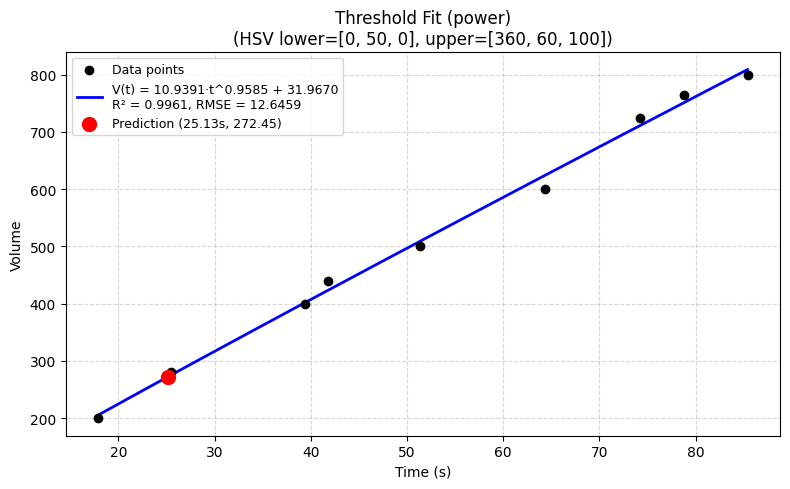

In [53]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def fit_threshold_curve(folder,
                        time=None,
                        method="HSV",
                        lower_hsv=[0, 75, 95],
                        upper_hsv=[360, 80, 100],
                        fit_type="auto"):
    """
    对单个文件夹执行阈值拟合，可选分数幂(0-1)、对数、线性拟合。
    返回拟合的曲线并可视化，图例上显示拟合方程式、R²、RMSE。
    若给定 time，则返回该时间在拟合曲线上的预测结果，并用红点标出。

    Parameters:
        folder (str): 文件夹路径
        time (float): 预测时间点（秒），可选
        method (str): 目前仅支持 "HSV"
        lower_hsv, upper_hsv (list): HSV阈值区间
        fit_type (str): "auto" | "log" | "linear" | "power"
                        auto 时自动在三种模型中选择 R² 最优且满足约束的模型

    Returns:
        float or None: 给定 time 时的预测 volume，若 time 为 None 则返回 None
    """
    fit_type = fit_type.lower()
    if fit_type not in ("auto", "log", "linear", "power"):
        raise ValueError("fit_type 必须是 'auto'、'log'、'linear' 或 'power' 之一")

    # 读取数据
    all_curves = batch_fit_color_curves(folder)

    # 提取满足阈值条件的 (time, volume) 点
    vol_time_dict = {}
    for vol_name, curves in all_curves.items():
        vol = float(vol_name)
        t = curves['time']
        matched = np.ones_like(t, dtype=bool)
        for p, lc, uc in zip(['H', 'S', 'V'], lower_hsv, upper_hsv):
            matched = matched & (curves[p] >= lc) & (curves[p] <= uc)
        idx = np.where(matched)[0]
        if len(idx) > 0:
            vol_time_dict[vol] = t[idx[0]]

    if len(vol_time_dict) < 2:
        raise ValueError(f"满足阈值条件的用量不足（仅 {len(vol_time_dict)} 个），无法拟合")

    volumes = np.array(list(vol_time_dict.keys()))
    times = np.array(list(vol_time_dict.values()))
    sort_idx = np.argsort(times)
    times = times[sort_idx]
    volumes = volumes[sort_idx]

    # 模型定义
    def log_model(t, a, b, c):
        return a * np.log(b * t + c)
    def linear_model(t, a, b):
        return a * t + b
    def power_model(t, a, b, c):
        return a * np.power(t, b) + c

    # 通用拟合尝试函数
    def _try_fit(model_func, p0, bounds, valid, name, formula_fmt):
        try:
            popt, _ = curve_fit(model_func, times, volumes, p0=p0, bounds=bounds, maxfev=20000)
            if valid is not None and not valid(popt):
                return None
            fitted = lambda t, p=popt: model_func(t, *p)
            v_pred = fitted(times)
            ss_res = ((volumes - v_pred) ** 2).sum()
            v_mean = volumes.mean()
            ss_tot = ((volumes - v_mean) ** 2).sum()
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
            rmse = np.sqrt(ss_res / len(times))
            formula = formula_fmt(*popt)
            return {
                'func': fitted, 'name': name, 'formula': formula,
                'r2': r2, 'rmse': rmse, 'popt': popt
            }
        except Exception:
            return None

    candidates = []

    # 对数拟合
    if fit_type in ("auto", "log"):
        res = _try_fit(
            log_model, p0=[1.0, 1.0, 1.0],
            bounds=([-np.inf, 1e-8, 1e-8], [np.inf, np.inf, np.inf]),
            valid=lambda p: p[0] > 0 and np.all(p[1] * times + p[2] > 0),
            name="log",
            formula_fmt=lambda a, b, c: f"V(t) = {a:.4f}·ln({b:.4f}·t + {c:.4f})"
        )
        if res:
            candidates.append(res)
        elif fit_type == "log":
            raise RuntimeError("对数模型拟合失败或参数不满足约束")

    # 线性拟合
    if fit_type in ("auto", "linear"):
        res = _try_fit(
            linear_model, p0=[1.0, 0.0],
            bounds=([-np.inf, -np.inf], [np.inf, np.inf]),
            valid=lambda p: p[0] > 0,
            name="linear",
            formula_fmt=lambda a, b: f"V(t) = {a:.4f}·t + {b:.4f}"
        )
        if res:
            candidates.append(res)
        elif fit_type == "linear":
            raise RuntimeError("线性模型拟合失败或斜率不满足单调递增约束")

    # 分数幂拟合 (0 < b ≤ 1)
    if fit_type in ("auto", "power"):
        res = _try_fit(
            power_model, p0=[1.0, 0.5, 0.0],
            bounds=([0, 1e-6, -np.inf], [np.inf, 1.0, np.inf]),
            valid=lambda p: p[0] > 0,
            name="power",
            formula_fmt=lambda a, b, c: f"V(t) = {a:.4f}·t^{b:.4f} + {c:.4f}"
        )
        if res:
            candidates.append(res)
        elif fit_type == "power":
            raise RuntimeError("分数幂模型拟合失败或参数不满足约束")

    if not candidates:
        raise RuntimeError("所有候选模型均拟合失败")

    # auto 模式下选择 R² 最高的模型
    best = max(candidates, key=lambda x: x['r2'])
    fitted_curve = best['func']
    fit_method = best['name']
    formula_text = best['formula']
    r2 = best['r2']
    rmse = best['rmse']

    # 预测
    predicted_volume = None
    if time is not None:
        predicted_volume = float(fitted_curve(time))

    # 可视化
    t_dense = np.linspace(times.min(), times.max(), 500)
    v_dense = fitted_curve(t_dense)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(times, volumes, color='black', zorder=5, label='Data points')
    line_label = f"{formula_text}\nR² = {r2:.4f}, RMSE = {rmse:.4f}"
    ax.plot(t_dense, v_dense, color='blue', linewidth=2, label=line_label)

    if predicted_volume is not None:
        ax.scatter([time], [predicted_volume], color='red', s=100, zorder=6,
                   label=f'Prediction ({time:.2f}s, {predicted_volume:.2f})')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Volume')
    ax.set_title(f'Threshold Fit ({fit_method})\n(HSV lower={lower_hsv}, upper={upper_hsv})')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return predicted_volume

fit = fit_threshold_curve(r"C:\Users\abc\Desktop\excel\excel",
                              time=25.13,
                              lower_hsv=[0, 50, 0],
                              upper_hsv=[360, 60, 100],
                              fit_type="power")

在前 2.0s 内 S > 85 的曲线:


C:\Users\abc\AppData\Local\Temp\ipykernel_28768\2143141552.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


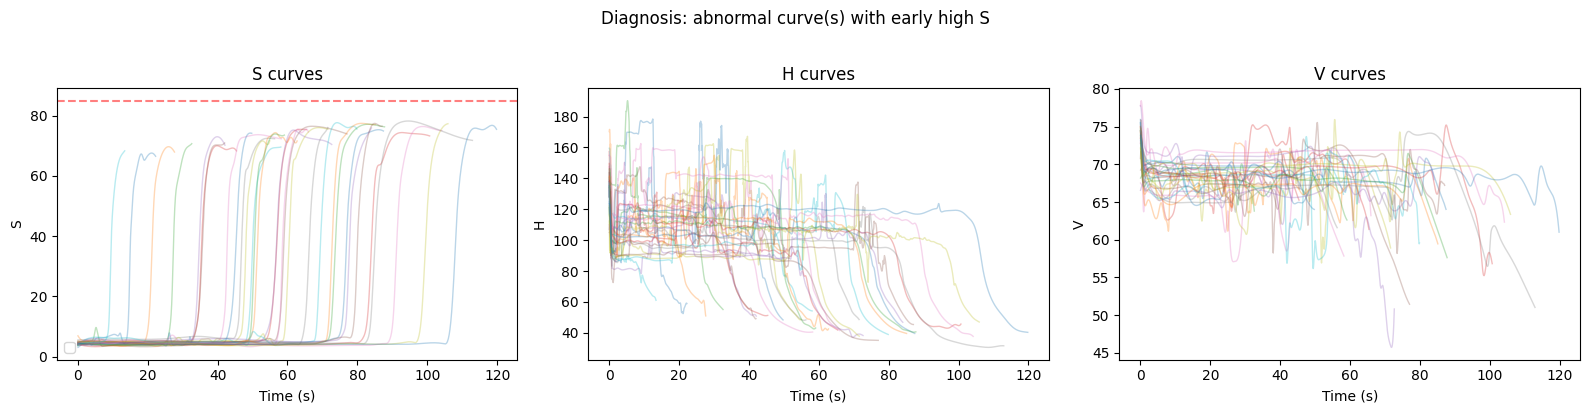

In [54]:
import matplotlib.pyplot as plt

# 诊断：找出在时间极短时 S 就到达高值（>80 或 >90）的异常曲线
threshold_s = 85  # 可调整
early_time_limit = 2.0  # 前 2 秒内

abnormal_volumes = []
for vol_name, curves in result_dict.items():
    t = curves['time']
    s = curves['S']
    early_mask = t <= early_time_limit
    if np.any(early_mask) and np.max(s[early_mask]) > threshold_s:
        abnormal_volumes.append((vol_name, np.max(s[early_mask]), t[early_mask][np.argmax(s[early_mask])]))

print(f"在前 {early_time_limit}s 内 S > {threshold_s} 的曲线:")
for vol, max_s, t_at in abnormal_volumes:
    print(f"  用量 {vol}: t={t_at:.3f}s 时 S={max_s:.2f}")

# 可视化：把这些异常曲线和正常曲线画在一起对比
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for vol_name, curves in result_dict.items():
    t = curves['time']
    kwargs = {'alpha': 0.3, 'linewidth': 1}
    if vol_name in [v[0] for v in abnormal_volumes]:
        kwargs = {'alpha': 1.0, 'linewidth': 2.5, 'label': f'abnormal: {vol_name}'}
    axes[0].plot(t, curves['S'], **kwargs)
    axes[1].plot(t, curves['H'], **kwargs)
    axes[2].plot(t, curves['V'], **kwargs)

axes[0].set_title('S curves')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('S')
axes[0].axhline(threshold_s, color='red', linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].set_title('H curves')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('H')

axes[2].set_title('V curves')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('V')

plt.suptitle('Diagnosis: abnormal curve(s) with early high S', y=1.02)
plt.tight_layout()
plt.show()

# 进一步：对比异常曲线和相邻用量的原始数据
def plot_raw_comparison(volume_names, folder_path):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
    for vol in volume_names:
        fp = os.path.join(folder_path, f"{vol}.xlsx")
        if not os.path.exists(fp):
            continue
        df_tmp = pd.read_excel(fp)
        axes[0].plot(df_tmp['Time (s)'], df_tmp['S (0-100)'], label=vol, marker='o', markersize=2)
        axes[1].plot(df_tmp['Time (s)'], df_tmp['H (0-360)'], label=vol, marker='o', markersize=2)
        axes[2].plot(df_tmp['Time (s)'], df_tmp['V (0-100)'], label=vol, marker='o', markersize=2)
    for ax, ttl in zip(axes, ['S', 'H', 'V']):
        ax.set_title(ttl)
        ax.set_xlabel('Time (s)')
        ax.legend()
    plt.suptitle('Raw data comparison (abnormal vs neighbors)')
    plt.tight_layout()
    plt.show()

if abnormal_volumes:
    target = abnormal_volumes[0][0]
    all_vols = sorted(result_dict.keys(), key=lambda x: float(x))
    idx = all_vols.index(target)
    neighbors = all_vols[max(0, idx-1):min(len(all_vols), idx+2)]
    print(f"\n对比异常曲线 {target} 与其相邻用量: {neighbors}")
    plot_raw_comparison(neighbors, r"C:\Users\abc\Desktop\ml\excel")


已处理: 100 (C:\Users\abc\Desktop\excel\am\100.xlsx)
已处理: 250 (C:\Users\abc\Desktop\excel\am\250.xlsx)
已处理: 300 (C:\Users\abc\Desktop\excel\am\300.xlsx)
已处理: 350 (C:\Users\abc\Desktop\excel\am\350.xlsx)
已处理: 400 (C:\Users\abc\Desktop\excel\am\400.xlsx)
已处理: 450 (C:\Users\abc\Desktop\excel\am\450.xlsx)
已处理: 500 (C:\Users\abc\Desktop\excel\am\500.xlsx)
已处理: 550 (C:\Users\abc\Desktop\excel\am\550.xlsx)
已处理: 600 (C:\Users\abc\Desktop\excel\am\600.xlsx)
已处理: 650 (C:\Users\abc\Desktop\excel\am\650.xlsx)
已处理: 700 (C:\Users\abc\Desktop\excel\am\700.xlsx)
已处理: 750 (C:\Users\abc\Desktop\excel\am\750.xlsx)
已处理: 800 (C:\Users\abc\Desktop\excel\am\800.xlsx)
已处理: 125 (C:\Users\abc\Desktop\excel\afternoon\125.xlsx)
已处理: 175 (C:\Users\abc\Desktop\excel\afternoon\175.xlsx)
已处理: 225 (C:\Users\abc\Desktop\excel\afternoon\225.xlsx)
已处理: 275 (C:\Users\abc\Desktop\excel\afternoon\275.xlsx)
已处理: 320 (C:\Users\abc\Desktop\excel\afternoon\320.xlsx)
已处理: 325 (C:\Users\abc\Desktop\excel\afternoon\325.xlsx)
已处理: 340

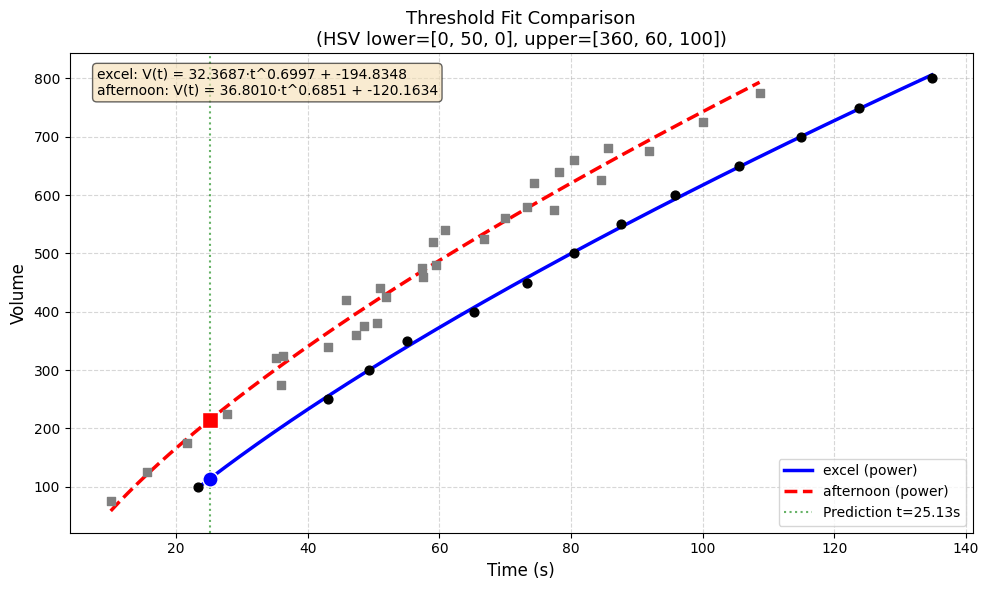


预测结果 (t=25.13s):
  excel: 114.06
  afternoon: 214.85


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

def compare_threshold_fits(folder1, folder2,
                           label1='Folder 1', label2='Folder 2',
                           time=None,
                           method="HSV",
                           lower_hsv=[0, 75, 95],
                           upper_hsv=[360, 80, 100],
                           fit_type="auto",
                           poly_degree=2):
    """
    对两个文件夹分别执行阈值拟合，并将拟合函数及数据点绘制在同一张图中对比。
    
    Parameters:
        folder1, folder2 (str): 两个文件夹路径
        label1, label2 (str): 图例标签
        time (float): 若提供，则在图上标出两个模型在该时间的预测点
        method (str): 目前仅支持 "HSV"
        lower_hsv, upper_hsv (list): HSV阈值区间
        fit_type (str): "auto" | "log" | "linear" | "power" | "poly" | "pchip"
        poly_degree (int): 多项式级数的最高阶数（fit_type="poly" 时生效，默认2）
    """
    fit_type = fit_type.lower()
    if fit_type not in ("auto", "log", "linear", "power", "poly", "pchip"):
        raise ValueError("fit_type 必须是 'auto'、'log'、'linear'、'power'、'poly' 或 'pchip' 之一")
    
    # 分别读取两个文件夹
    curves1 = batch_fit_color_curves(folder1)
    curves2 = batch_fit_color_curves(folder2)
    
    def _extract_data(all_curves):
        """从 all_curves 中提取满足阈值条件的 (volume, time) 点。"""
        vol_time_dict = {}
        for vol_name, curves in all_curves.items():
            vol = float(vol_name)
            t = curves['time']
            matched = np.ones_like(t, dtype=bool)
            for p, lc, uc in zip(['H', 'S', 'V'], lower_hsv, upper_hsv):
                matched = matched & (curves[p] >= lc) & (curves[p] <= uc)
            idx = np.where(matched)[0]
            if len(idx) > 0:
                vol_time_dict[vol] = t[idx[0]]
        
        if len(vol_time_dict) < 2:
            raise ValueError(f"满足阈值条件的用量不足（仅 {len(vol_time_dict)} 个），无法拟合")
        
        volumes = np.array(list(vol_time_dict.keys()))
        times = np.array(list(vol_time_dict.values()))
        sort_idx = np.argsort(times)
        return times[sort_idx], volumes[sort_idx]
    
    def _fit_and_label(times, volumes):
        """根据 fit_type 进行拟合，返回 (fitted_curve, fit_method, formula_text)。"""
        def log_model(t, a, b, c):
            return a * np.log(b * t + c)
        def linear_model(t, a, b):
            return a * t + b
        def power_model(t, a, b, c):
            return a * np.power(t, b) + c
        
        fitted_curve = None
        fit_method = None
        formula_text = ""
        
        # log
        if fit_type in ("auto", "log"):
            try:
                popt, _ = curve_fit(log_model, times, volumes, p0=[1.0, 1.0, 1.0], maxfev=10000)
                a, b, c = popt
                if a > 0 and np.all(b * times + c > 0):
                    fitted_curve = lambda t: log_model(t, a, b, c)
                    fit_method = "log"
                    formula_text = f"V(t) = {a:.4f}·ln({b:.4f}·t + {c:.4f})"
                elif fit_type == "log":
                    raise RuntimeError("对数模型参数不符合单调约束")
            except Exception as e:
                if fit_type == "log":
                    raise RuntimeError(f"对数模型拟合失败: {e}")
        
        # linear
        if fitted_curve is None and fit_type in ("auto", "linear"):
            try:
                popt, _ = curve_fit(linear_model, times, volumes)
                a, b = popt
                if a > 0:
                    fitted_curve = lambda t: linear_model(t, a, b)
                    fit_method = "linear"
                    formula_text = f"V(t) = {a:.4f}·t + {b:.4f}"
                elif fit_type == "linear":
                    raise RuntimeError("线性模型斜率不满足单调递增约束")
            except Exception as e:
                if fit_type == "linear":
                    raise RuntimeError(f"线性模型拟合失败: {e}")
        
        # power law (fractional exponent)
        if fitted_curve is None and fit_type in ("auto", "power"):
            try:
                popt, _ = curve_fit(power_model, times, volumes, p0=[1.0, 0.5, 0.0], maxfev=10000)
                a, b, c = popt
                if a > 0 and b > 0:
                    fitted_curve = lambda t: power_model(t, a, b, c)
                    fit_method = "power"
                    formula_text = f"V(t) = {a:.4f}·t^{b:.4f} + {c:.4f}"
                elif fit_type == "power":
                    raise RuntimeError("幂律模型参数不符合单调约束")
            except Exception as e:
                if fit_type == "power":
                    raise RuntimeError(f"幂律模型拟合失败: {e}")
        
        # polynomial series
        if fitted_curve is None and fit_type in ("auto", "poly"):
            try:
                max_degree = min(poly_degree, len(times) - 1)
                if max_degree < 0:
                    max_degree = 1
                coeffs = np.polyfit(times, volumes, deg=max_degree)
                deriv_coeffs = np.polyder(coeffs)
                deriv_vals = np.polyval(deriv_coeffs, times)
                if np.all(deriv_vals >= -1e-6):
                    fitted_curve = lambda t: np.polyval(coeffs, t)
                    fit_method = f"poly_{max_degree}"
                    terms = []
                    for i, c in enumerate(coeffs):
                        power = max_degree - i
                        if abs(c) < 1e-8:
                            continue
                        if power == 0:
                            terms.append(f"{c:.4f}")
                        elif power == 1:
                            terms.append(f"{c:.4f}·t")
                        else:
                            terms.append(f"{c:.4f}·t^{power}")
                    formula_text = "V(t) = " + " + ".join(terms) if terms else "V(t) = 0"
                elif fit_type == "poly":
                    raise RuntimeError(f"多项式({max_degree}阶)在数据范围内不单调递增")
            except Exception as e:
                if fit_type == "poly":
                    raise RuntimeError(f"多项式拟合失败: {e}")
        
        # pchip fallback
        if fitted_curve is None:
            pchip = PchipInterpolator(times, volumes)
            fitted_curve = lambda t: pchip(t)
            fit_method = "pchip"
            formula_text = "V(t) = PCHIP interpolation"
        
        return fitted_curve, fit_method, formula_text
    
    # 提取数据并拟合
    t1, v1 = _extract_data(curves1)
    t2, v2 = _extract_data(curves2)
    
    f1, method1, text1 = _fit_and_label(t1, v1)
    f2, method2, text2 = _fit_and_label(t2, v2)
    
    # 绘图
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # folder1
    ax.scatter(t1, v1, color='black', s=40, zorder=5)
    t_dense1 = np.linspace(t1.min(), t1.max(), 500)
    ax.plot(t_dense1, f1(t_dense1), color='blue', linewidth=2.5, label=f'{label1} ({method1})')
    
    # folder2
    ax.scatter(t2, v2, color='gray', s=40, zorder=5, marker='s')
    t_dense2 = np.linspace(t2.min(), t2.max(), 500)
    ax.plot(t_dense2, f2(t_dense2), color='red', linewidth=2.5, linestyle='--', label=f'{label2} ({method2})')
    
    # 若给定 time，标出预测点
    if time is not None:
        pred1 = float(f1(time))
        pred2 = float(f2(time))
        ax.scatter([time], [pred1], color='blue', s=120, zorder=6, marker='o', edgecolors='white')
        ax.scatter([time], [pred2], color='red', s=120, zorder=6, marker='s', edgecolors='white')
        ax.axvline(time, color='green', linestyle=':', alpha=0.6, label=f'Prediction t={time:.2f}s')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Volume', fontsize=12)
    ax.set_title(f'Threshold Fit Comparison\n(HSV lower={lower_hsv}, upper={upper_hsv})', fontsize=13)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # 显示拟合表达式
    info_text = f"{label1}: {text1}\n{label2}: {text2}"
    ax.text(0.03, 0.97, info_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
    
    plt.tight_layout()
    plt.show()
    
    # 打印预测结果
    if time is not None:
        print(f"\n预测结果 (t={time:.2f}s):")
        print(f"  {label1}: {pred1:.2f}")
        print(f"  {label2}: {pred2:.2f}")

# 示例调用
compare_threshold_fits(
    r"C:\Users\abc\Desktop\excel\excel",
    r"C:\Users\abc\Desktop\excel\afternoon",
    label1="excel",
    label2="afternoon",
    time=25.13,
    lower_hsv=[0, 50, 0],
    upper_hsv=[360, 60, 100],
    fit_type="power",
    poly_degree=2
)


已处理: 200 (C:\Users\abc\Desktop\excel\excel\200.xlsx)
已处理: 280 (C:\Users\abc\Desktop\excel\excel\280.xlsx)
已处理: 400 (C:\Users\abc\Desktop\excel\excel\400.xlsx)
已处理: 440 (C:\Users\abc\Desktop\excel\excel\440.xlsx)
已处理: 500 (C:\Users\abc\Desktop\excel\excel\500.xlsx)
已处理: 600 (C:\Users\abc\Desktop\excel\excel\600.xlsx)
已处理: 725 (C:\Users\abc\Desktop\excel\excel\725.xlsx)
已处理: 765 (C:\Users\abc\Desktop\excel\excel\765.xlsx)
已处理: 800 (C:\Users\abc\Desktop\excel\excel\800.xlsx)


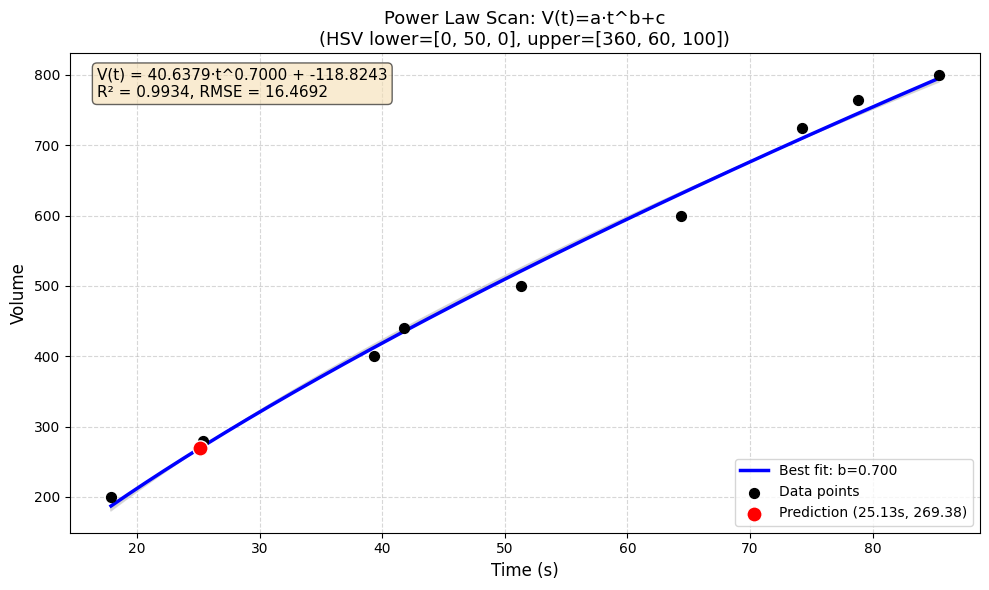


最佳拟合: b=0.7000, a=40.6379, c=-118.8243, R²=0.9934, RMSE=16.4692
预测 t=25.13s 时 Volume=269.38

       b          a          c         R²       RMSE
-------------------------------------------------------
  0.7000    40.6379  -118.8243     0.9934    16.4692
  0.6900    42.8367  -126.9191     0.9931    16.7403
  0.6800    45.1628  -135.2515     0.9929    17.0178
  0.6700    47.6245  -143.8321     0.9927    17.3015
  0.6600    50.2303  -152.6724     0.9924    17.5912
  0.6500    52.9896  -161.7844     0.9922    17.8865
  0.6400    55.9125  -171.1807     0.9919    18.1872
  0.6300    59.0095  -180.8749     0.9916    18.4931
  0.6200    62.2924  -190.8815     0.9914    18.8040
  0.6100    65.7734  -201.2159     0.9911    19.1197
  0.6000    69.4659  -211.8945     0.9908    19.4399


In [56]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def fit_power_range(time,
                    lower_hsv=[0, 50, 0],
                    upper_hsv=[360, 60, 100],
                    b_range=None,
                    b_list=None,
                    all_curves=None,
                    plot_all=True):
    """
    在指定的幂指数 b 范围内扫描，固定 b 后拟合 V(t)=a·t^b+c，
    根据 R² 选出最优拟合，并可视化对比。
    
    Parameters:
        time (float): 目标预测时间（s）
        lower_hsv, upper_hsv (list): HSV 阈值区间
        b_range (tuple): (b_min, b_max, b_step)，如 (0.6, 0.7, 0.01)
        b_list (list): 直接给定 b 的列表，如 [0.6, 0.65, 0.7]
        all_curves (dict): 数据字典（如 result_dict）
        plot_all (bool): 是否把所有候选幂律曲线画在背景上
        
    Returns:
        dict: 包含最佳参数、R²、RMSE、预测值及完整结果表
    """
    if all_curves is None:
        raise ValueError("请传入 all_curves 参数")
    
    # 1. 提取数据点
    vol_time_dict = {}
    for vol_name, curves in all_curves.items():
        vol = float(vol_name)
        t = curves['time']
        matched = np.ones_like(t, dtype=bool)
        for p, lc, uc in zip(['H', 'S', 'V'], lower_hsv, upper_hsv):
            matched = matched & (curves[p] >= lc) & (curves[p] <= uc)
        idx = np.where(matched)[0]
        if len(idx) > 0:
            vol_time_dict[vol] = t[idx[0]]
    
    if len(vol_time_dict) < 2:
        raise ValueError(f"满足阈值条件的用量不足（仅 {len(vol_time_dict)} 个），无法拟合")
    
    volumes = np.array(list(vol_time_dict.keys()))
    times   = np.array(list(vol_time_dict.values()))
    sort_idx = np.argsort(times)
    times   = times[sort_idx]
    volumes = volumes[sort_idx]
    
    # 2. 构造 b 列表
    if b_list is not None:
        b_candidates = np.array(b_list, dtype=float)
    elif b_range is not None:
        b_min, b_max, b_step = b_range
        b_candidates = np.arange(b_min, b_max + b_step/2, b_step)

    else:
        raise ValueError("必须提供 b_range 或 b_list 之一")
    
    # 3. 对每个 b 固定后拟合 a, c
    results = []
    v_mean = volumes.mean()
    ss_tot = ((volumes - v_mean) ** 2).sum()
    
    for b in b_candidates:
        def _model(t, a, c):
            return a * np.power(t, b) + c
        
        try:
            # 初始猜测 a=1, c=0
            popt, _ = curve_fit(_model, times, volumes, p0=[1.0, 0.0], maxfev=10000)
            a, c = popt
            if a <= 0:
                raise RuntimeError("a <= 0，不满足单调递增")
            
            v_pred = _model(times, a, c)
            ss_res = ((volumes - v_pred) ** 2).sum()
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
            rmse = np.sqrt(ss_res / len(times))
            
            results.append({
                'b': b,
                'a': a,
                'c': c,
                'r2': r2,
                'rmse': rmse,
                'model': lambda t, a=a, c=c, b=b: a * np.power(t, b) + c
            })
        except Exception as e:
            print(f"  b={b:.3f} 拟合失败: {e}")
            continue
    
    if not results:
        raise RuntimeError("所有 b 候选值均拟合失败")
    
    # 4. 按 R² 排序选最优
    results_sorted = sorted(results, key=lambda x: x['r2'], reverse=True)
    best = results_sorted[0]
    
    # 5. 可视化
    fig, ax = plt.subplots(figsize=(10, 6))
    t_dense = np.linspace(times.min(), times.max(), 500)
    
    if plot_all:
        for r in results:
            ax.plot(t_dense, r['model'](t_dense), color='lightgray',
                    linewidth=1, alpha=0.6, zorder=1)
    
    # 最佳拟合曲线
    ax.plot(t_dense, best['model'](t_dense), color='blue',
            linewidth=2.5, zorder=3, label=f"Best fit: b={best['b']:.3f}")
    
    # 数据点
    ax.scatter(times, volumes, color='black', s=50, zorder=4, label='Data points')
    
    # 预测点
    pred_vol = float(best['model'](time))
    ax.scatter([time], [pred_vol], color='red', s=120, zorder=5,
               marker='o', edgecolors='white', label=f'Prediction ({time:.2f}s, {pred_vol:.2f})')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Volume', fontsize=12)
    ax.set_title(f'Power Law Scan: V(t)=a·t^b+c\n(HSV lower={lower_hsv}, upper={upper_hsv})', fontsize=13)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # 公式文本框
    formula_text = f"V(t) = {best['a']:.4f}·t^{best['b']:.4f} + {best['c']:.4f}\nR² = {best['r2']:.4f}, RMSE = {best['rmse']:.4f}"
    ax.text(0.03, 0.97, formula_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
    
    plt.tight_layout()
    plt.show()
    
    # 6. 打印结果表
    print(f"\n最佳拟合: b={best['b']:.4f}, a={best['a']:.4f}, c={best['c']:.4f}, R²={best['r2']:.4f}, RMSE={best['rmse']:.4f}")
    print(f"预测 t={time:.2f}s 时 Volume={pred_vol:.2f}\n")
    print(f"{'b':>8} {'a':>10} {'c':>10} {'R²':>10} {'RMSE':>10}")
    print("-" * 55)
    for r in results_sorted:
        print(f"{r['b']:>8.4f} {r['a']:>10.4f} {r['c']:>10.4f} {r['r2']:>10.4f} {r['rmse']:>10.4f}")
    
    return {
        'best': best,
        'prediction': pred_vol,
        'all_results': results_sorted,
        'times': times,
        'volumes': volumes
    }


folder = r"C:\Users\abc\Desktop\excel\excel"
result_dict = batch_fit_color_curves(folder)
# 示例调用：在 b=0.6~0.7 范围内以步长 0.01 扫描
fit_result = fit_power_range(
    time=25.13,
    lower_hsv=[0, 50, 0],
    upper_hsv=[360, 60, 100],
    b_range=(0.6, 0.7, 0.01),
    all_curves=result_dict,
    plot_all=True
)

# 或者直接用列表指定 b
# fit_result = fit_power_range(
#     time=25.13,
#     lower_hsv=[0, 50, 0],
#     upper_hsv=[360, 60, 100],
#     b_list=[0.6, 0.65, 0.7],
#     all_curves=result_dict,
#     plot_all=True
# )
